# Amasya İli İlçelerinde Elektrik Tüketim ve Ödeme Davranışlarının Analizi

## Notebook_03: Veri Hikayesi Anlatımı ve İçgörüleri

## Problem Tanımı

Bu çalışmada şu sorulara cevap aranmıştır:

1. İlçeler arasında tüketim farkı var mı?
2. Bu farkın nedeni müşteri profili mi, hesap sınıfı dağılımı mı, yoksa mevsimsellik mi?
3. Müşteriler tüketim davranışına göre anlamlı segmentlere ayrılabilir mi?

## Hipotezler

- H1: İlçeler arası tüketim farkının temel nedeni tipik hane tüketimi değil, yüksek tüketimli müşteri yoğunluğudur.
- H2: Ticari abonelik oranı yüksek ilçelerde ortalama tüketim daha yüksektir.
- H3: İlçeler benzer mevsimsel desen gösterir; dolayısıyla farkın ana kaynağı mevsimsellik değildir.
- H4: Müşteriler tüketim seviyelerine göre segmentlere ayrıldığında farklı iş stratejileri geliştirilebilir.

### 1. Veri Yükleme

In [1]:
import pandas as pd
import numpy as np

file_path = "elektrik_veri_hashed.xlsx"
xls = pd.ExcelFile(file_path)

print("Sayfa İsimleri: " , xls.sheet_names)

df_tahsilat = pd.read_excel(xls, sheet_name="Tahsilat")       # ödeme işlemleri
df_tahsilat_1 = pd.read_excel(xls, sheet_name="Tahsilat 1")   # fatura işlemleri
df_tahakkuk = pd.read_excel(xls, sheet_name="Tahakkuk")       # Hamamözü
df_tahakkuk_1 = pd.read_excel(xls, sheet_name="Tahakkuk 1")   # Gümüşhacıköy
df_tahakkuk_2 = pd.read_excel(xls, sheet_name="Tahakkuk 2")   # Göynücek

df_tahakkuk_all=pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2], ignore_index=True)

Sayfa İsimleri:  ['Tahsilat', 'Tahsilat 1', 'Tahakkuk', 'Tahakkuk 1', 'Tahakkuk 2']


In [2]:
# Negatif kWh'leri analiz dışı bırakıyoruz.
df_analysis = df_tahakkuk_all[df_tahakkuk_all["kwh"] >=0].copy()

### 2. İlçe Karşılaştırma Analizi

İlk adımda ilçeler arası genel tüketim farkı incelenmiştir.
Bu amaçla medyan, ortalama, maksimum tüketim ve kayıt sayıları karşılaştırılmıştır.

Medyan değer, aşırı uç tüketimlerden daha az etkilendiği için
tipik müşteri davranışını temsil etmekte kullanılmıştır.

In [3]:
# İlçe bazlı temel özet
ilce_ozet = df_analysis.groupby("ilce")["kwh"].agg(medyan = "median", ortalama = "mean", max_kwh = "max", kayit_sayisi = "count").sort_values("medyan",ascending=False)
ilce_ozet

,medyan,ortalama,max_kwh,kayit_sayisi
ilce,,,,
GÜMÜŞHACIKÖY,48.32,97.473146,153575.73,765550
GÖYNÜCEK,45.10,89.736998,105687.69,295183
HAMAMÖZÜ,40.56,70.892741,25941.60,124814


### Bulgular

İlçeler arası medyan değerleri yakın. Bu durum mesken müşterisinin elektrik tüketimi davranışı ilçeden bağımsız benzer olduğunu görüyoruz.

Ortalama değerler medyana göre belirgin şekilde yüksek çıktı. Bu da az sayıda ama elektrik tüketimi yüksek olan müşteriler dağılımı yukarı çekiyor.

Gümüşhacıköy ilçesinde maksimum elektrik tüketimi diğer ilçelere kıyasla çok daha yüksek. Bu da ticari veya sanayi tipi abonelerin daha yoğun olduğuna işaret ediyor.

#### İlçelerdeki Hesap Sınıfı Dağılımının Elektrik Tüketimine Etkisi

In [4]:
# 37 farklı Hesap Sınıfını ayrı ayrı incelemk yerine gruplayalak analiz edelim.

ticari_siniflar = [
    "Ticari Faaliyet - Yazıhane",
    "Şantiye ve Geçici Aboneler",
    "İç Tüketim",
    "Balıkçılık ve Su Ürünleri Yetiştiriciliğ",
    "Büyükbaş-Küçükbaş Hayvancılık",
    "Aritma Tesisleri",
    "Belediye Park Bahçe Aydınlatma",
    "İçme-Kullanma Suyu (Belediye)"
]

kamu_siniflar = [
    "1 SAYILI CETVELDE YER ALAN KAMU İDARESİ",
    "Belediye",
    "Cemevleri",
    "Diyanet Kuran Kursu",
    "İbadethane Aydınlatma",
    "İbadethane Isıtma/Soğutma/Lojman",
    "Şehit Aileleri ve Gaziler",
    "Ölçümsüz Aboneler (Resmi Daire)"
]

def sinif_grup(x):
    if x in ticari_siniflar:
        return "Ticari"
    elif x in kamu_siniflar:
        return "Kamu"
    else:
        return "Konut/Diğer"

df_analysis["sinif_grup"] = df_analysis["Hesap Sınıfı"].apply(sinif_grup)


In [5]:
# İlçe bazlı hesap sınıfı oranları
ilce_sinif_oran = (pd.crosstab(df_analysis["ilce"],df_analysis["sinif_grup"],normalize="index") * 100).round(2)
ilce_sinif_oran

sinif_grup,Kamu,Konut/Diğer,Ticari
ilce,,,
GÖYNÜCEK,2.66,89.68,7.66
GÜMÜŞHACIKÖY,2.09,88.74,9.17
HAMAMÖZÜ,3.03,90.49,6.47


### Bulgular

Hesap sınıfları üç ana grupta incelendiğinde,
Gümüşhacıköy ilçesinde ticari abonelik oranının diğer ilçelere göre daha yüksek olduğu görülmüştür.

Konut/Diğer oranı üç ilçede de benzer seviyededir.
Bu durum, medyan tüketimlerin birbirine yakın olmasını açıklamaktadır.

Dolayısıyla ilçeler arası ortalama tüketim farkının temel nedenlerinden biri
ticari abonelik yoğunluğudur.


### 3. Mevsimselliğin Elektrik Tüketimine Etkisi

In [6]:
# Tarih alanını dönüştürüp ay bilgisini üretiyoruz
df_analysis["fatura_tarihi"] = pd.to_datetime(df_analysis["fatura_tarihi"])
df_analysis["ay"] = df_analysis["fatura_tarihi"].dt.month

aylik_ilce = df_analysis.groupby(["ilce", "ay"])["kwh"].mean().reset_index()

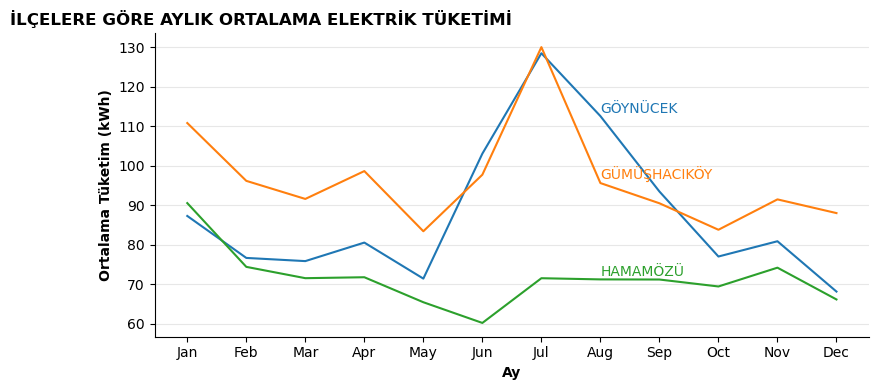

In [7]:
import matplotlib.pyplot as plt
import calendar

plt.figure(figsize=(8,4))
ax=plt.gca()
for ilce in aylik_ilce["ilce"].unique():
    data1 = aylik_ilce[aylik_ilce["ilce"] == ilce]
    line,=plt.plot(data1["ay"], data1["kwh"], label = ilce)
    ax.text(data1["ay"].iloc[-5],data1["kwh"].iloc[-5],ilce,va="bottom",ha="left", color=line.get_color() )
plt.xticks(range(1, 13), calendar.month_abbr[1:13])
plt.xlabel("Ay", fontweight="bold")
plt.ylabel("Ortalama Tüketim (kWh)", fontweight="bold")
plt.title("İLÇELERE GÖRE AYLIK ORTALAMA ELEKTRİK TÜKETİMİ", fontsize=12, fontweight="bold", horizontalalignment="right",color="k")


plt.tight_layout()

ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


### Bulgular

1) İlçe bazlı analiz sonucunda medyan tüketim değerlerinin
birbirine yakın olduğu görülmüştür. Bu durum,
tipik hane tüketiminin ilçeler arasında benzer olduğunu
göstermektedir.

2) Ortalama ve maksimum tüketim değerleri incelendiğinde
Gümüşhacıköy ilçesinin daha yüksek değerlere sahip olduğu
tespit edilmiştir.

3) Hesap sınıfları gruplandırıldığında,
Gümüşhacıköy ilçesinde ticari abonelik oranının
daha yüksek olduğu görülmüştür.

4) Aylık ortalama tüketim grafikleri incelendiğinde
tüm ilçelerin benzer mevsimsel desen gösterdiği
(yaz aylarında artış, kış aylarında düşüş)
tespit edilmiştir.

5) Dolayısıyla ilçeler arası tüketim farklılığının
temel nedeni mevsimsel faktörler değil,
ticari abonelik yoğunluğu ve yüksek tüketimli
müşteri varlığıdır.


### 4. Müşteri Segmentasyonu

Amaç:
Müşterileri tüketim ve ödeme davranışına göre gruplandırmak.

In [8]:
musteri_ozet = (
    df_analysis
    .groupby("sozlesme_hesap_no")
    .agg(
        ortalama_tuketim=("kwh", "mean"),
        medyan_tuketim=("kwh", "median")
    )
    .reset_index()
)

low_threshold = musteri_ozet["medyan_tuketim"].quantile(0.33)
high_threshold = musteri_ozet["medyan_tuketim"].quantile(0.66)

def segment_belirle(x):
    if x <= low_threshold:
        return "Düşük Tüketim"
    elif x <= high_threshold:
        return "Orta Tüketim"
    else:
        return "Yüksek Tüketim"

musteri_ozet["segment"] = musteri_ozet["medyan_tuketim"].apply(segment_belirle)

### 5. Tahsilat Performans Analizi

In [10]:
musteri_ozet = df_analysis.groupby("sozlesme_hesap_no").agg(ortalama_tuketim=("kwh", "mean"),medyan_tuketim=("kwh", "median")).reset_index()

low_threshold = musteri_ozet["medyan_tuketim"].quantile(0.33)
high_threshold = musteri_ozet["medyan_tuketim"].quantile(0.66)

def segment_belirle(x):
    if x <= low_threshold:
        return "Düşük Tüketim"
    elif x <= high_threshold:
        return "Orta Tüketim"
    else:
        return "Yüksek Tüketim"

musteri_ozet["segment"] = musteri_ozet["medyan_tuketim"].apply(segment_belirle)

In [11]:
#ödeme kategorisi
df_odeme = df_tahsilat_1.copy()

df_odeme["zamaninda_odeme"] = (
    df_odeme["Son Ödeme Tarihinden Önceki Tahsilat"].fillna(0) +
    df_odeme["Son Ödeme Tarihindeki Tahsilat"].fillna(0)
)

df_odeme["gec_odeme"] = (
    df_odeme["Son Ödeme (1)"].fillna(0) +
    df_odeme["Son Ödeme (2)"].fillna(0) +
    df_odeme["Son Ödeme (3)"].fillna(0) +
    df_odeme["Son Ödeme (4)"].fillna(0) +
    df_odeme["Son Ödeme (5)"].fillna(0) +
    df_odeme["Son Ödeme (6-10)"].fillna(0) +
    df_odeme["Son Ödeme (10-20)"].fillna(0) +
    df_odeme["Son Ödeme (20-30)"].fillna(0) +
    df_odeme["Son Ödeme (30-60)"].fillna(0) +
    df_odeme["Son Ödeme (60-90)"].fillna(0) +
    df_odeme["Son Ödeme (90-120)"].fillna(0) +
    df_odeme["Son Ödeme (120-150)"].fillna(0) +
    df_odeme["Son Ödeme (150-180)"].fillna(0) +
    df_odeme["Son Ödeme (180+)"].fillna(0)
)

In [12]:
#risk etiketi
df_odeme["risk_grubu"] = df_odeme.apply(
    lambda x: "Riskli" if x["gec_odeme"] > 0 else "Düzenli",
    axis=1
)

In [13]:
#İlçe bazlı risk analizi
risk_ilce = (
    df_odeme
    .groupby(["İlçe","risk_grubu"])
    .size()
    .unstack()
)

risk_ilce["Toplam"] = risk_ilce.sum(axis=1)

risk_ilce["Risk Oranı (%)"] = (
    risk_ilce["Riskli"] / risk_ilce["Toplam"] * 100
).round(2)

risk_ilce

risk_grubu,Düzenli,Riskli,Toplam,Risk Oranı (%)
İlçe,,,,
GÖYNÜCEK,83656,37176,120832,30.77
GÜMÜŞHACIKÖY,234154,77110,311264,24.77
HAMAMÖZÜ,35764,14378,50142,28.67
TAŞOVA,314604,120790,435394,27.74


### İlçe Bazlı Ödeme Riski

İlçe bazında gecikmeli ödeme oranları incelendiğinde ilçeler arasında belirgin farklar görülmektedir.

Göynücek ilçesi yaklaşık %30 gecikmeli ödeme oranı ile en yüksek tahsilat riskine sahiptir.

Hamamözü ve Taşova ilçelerinde risk oranı yaklaşık %28 civarındadır ve orta seviyede tahsilat riski göstermektedir.

Gümüşhacıköy ilçesi ise yaklaşık %24 risk oranı ile diğer ilçelere göre daha düşük gecikmeli ödeme oranına sahiptir.

Bu sonuçlar tahsilat süreçlerinin özellikle Göynücek ilçesinde daha yakından takip edilmesi gerektiğini göstermektedir.

In [14]:
#hesap sınıfına göre risk
risk_sinif = (
    df_odeme
    .groupby(["Hesap Sınıfı","risk_grubu"])
    .size()
    .unstack()
    .sort_values("Riskli",ascending=False)
)



risk_sinif["Toplam"] = risk_sinif.sum(axis=1)

risk_sinif["Risk Oranı (%)"] = (
    risk_sinif["Riskli"] / risk_sinif["Toplam"] * 100
).round(2)

risk_sinif.head(10)

risk_grubu,Düzenli,Riskli,Toplam,Risk Oranı (%)
Hesap Sınıfı,,,,
Mesken,584910.0,212932.0,797842.0,26.69
Ticari Faaliyet - Yazıhane,48224.0,21777.0,70001.0,31.11
Tarımsal Faaliyetler (Şahıs),7018.0,2618.0,9636.0,27.17
Şantiye ve Geçici Aboneler,4272.0,2479.0,6751.0,36.72
İbadethane Isıtma/Soğutma/Lojman,5938.0,1699.0,7637.0,22.25
İbadethane Aydınlatma,4209.0,1113.0,5322.0,20.91
1 SAYILI CETVELDE YER ALAN KAMU İDARESİ,2726.0,1107.0,3833.0,28.88
"Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)",3300.0,867.0,4167.0,20.81
Belediye,532.0,789.0,1321.0,59.73


### Hesap Sınıfına Göre Tahsilat Riski

Hesap sınıfı bazlı analiz, ödeme davranışının müşteri türüne göre önemli ölçüde değiştiğini göstermektedir.

En yüksek gecikmeli ödeme oranı %59 ile belediye aboneliklerinde görülmektedir. Bu durum kamu kurumlarına ait ödemelerin zaman zaman gecikmeli yapılabildiğini göstermektedir.

Köy içme suyu temini ve dağıtımı tesislerinde de yaklaşık %55 oranında yüksek bir gecikme riski bulunmaktadır.

Şantiye ve geçici abonelerde gecikmeli ödeme oranı %36  seviyesindedir. Bu müşteri grubu geçici faaliyetler yürüttüğü için ödeme davranışları daha düzensiz olabilir.

Ticari faaliyet abonelerinde gecikmeli ödeme oranı %31 seviyesindedir ve mesken abonelerine göre daha yüksek bir tahsilat riski oluşturmaktadır.

Mesken aboneleri ise %26 gecikmeli ödeme oranı ile daha stabil bir ödeme davranışı sergilemektedir.

### Tahsilat Süreçlerini İyileştirmek İçin Öneriler

1. **Bölgesel Tahsilat Stratejisi**
   Göynücek ilçesinde gecikmeli ödeme oranı daha yüksek olduğu için tahsilat süreçleri bu bölgede daha yakından takip edilmelidir.

2. **Yüksek Riskli Aboneler İçin Erken Uyarı Sistemi**
   Özellikle belediye, su dağıtım tesisleri ve şantiye aboneleri gibi yüksek gecikme oranına sahip müşteri grupları için erken uyarı ve ödeme hatırlatma sistemleri uygulanabilir.

3. **Ticari Müşteriler İçin Otomatik Ödeme Teşviki**
   Ticari faaliyet abonelerinde gecikme oranı daha yüksek olduğu için otomatik ödeme ve dijital ödeme kanalları teşvik edilebilir.

4. **Risk Skorlama Modeli**
   Müşterilerin geçmiş ödeme davranışları kullanılarak bir tahsilat risk skoru oluşturulabilir ve yüksek riskli müşteriler öncelikli olarak takip edilebilir.